In [2]:
import pandas as pd
import csv

In [3]:
df = pd.read_csv("Test3_combined.csv", delimiter = ',', encoding='utf-8')

In [4]:
df.head()

,ID,text,tag_tamara,tag_katja,comments_tamara,comments_katja,flagged_tamara,flagged_katja,chair,final_tag
0,ParlaMint-SI_2004-01-27-SDZ3-Redna-33.u194,"Magister Drobnič, ste želeli besedo? Prosim.",P_Neutral,P_Neutral,Procedural.,Procedural,NaN,NaN,True,NaN
1,ParlaMint-SI_2015-07-14-SDZ7-Redna-10.u428,"Gospa Anja Bah Žibert, imate besedo, da zahtev...",P_Neutral,P_Neutral,Procedural.,Procedural,NaN,NaN,True,NaN
2,ParlaMint-SI_2008-03-05-SDZ4-Izredna-34.u28,Hvala lepa. No sedaj smo pravzaprav lahko vide...,Negative,Negative,"Clear sentiment, negative opinion, reproachful...","Very negative, attack on the minister and crit...",NaN,NaN,False,NaN
3,ParlaMint-SI_2006-05-24-SDZ4-Redna-17.u82,Hvala lepa. Samo na kratko. Vlada podpira aman...,Positive,P_Neutral,Since the word ''podpira'' is used I would say...,"Very neutral, procedural - support to amend th...",1.0,NaN,False,NaN
4,ParlaMint-SI_2002-09-24-SDZ3-Redna-18.u52,"Spoštovana predsedujoča! Gospa ministrica, kol...",M_Negative,M_Negative,A very mixed sentiment sentence. On the one ha...,Speaker takes a position of having the topic o...,1.0,1.0,False,NaN


# 6-level schema analysis (Cohen's Kappa (κ))

In [5]:
from sklearn.metrics import cohen_kappa_score
annotator1 = df['tag_tamara']
annotator2 = df['tag_katja']
cohen_kappa_score(annotator1, annotator2)

np.float64(0.7877501516070345)

# κ for non-procedural and procedural speech


In [6]:
df_non = df[df['chair'] != True]

In [7]:
df_procedural = df[df['chair'] == True]

In [8]:
#df_procedural

In [9]:
annotator1 = df_non['tag_tamara']
annotator2 = df_non['tag_katja']
cohen_kappa_score(annotator1, annotator2)

np.float64(0.6551724137931034)

In [10]:
annotator1_procedural = df_procedural['tag_tamara']
annotator2_procedural = df_procedural['tag_katja']
cohen_kappa_score(annotator1_procedural, annotator2_procedural)

np.float64(0.736842105263158)

# 3-level analysis (Cohen's Kappa (κ))

In [11]:
df.loc[(df['tag_tamara'] == 'Negative') | (df['tag_tamara'] == 'M_Negative'), 'sent_tamara'] = 'Negative'
df.loc[(df['tag_tamara'] == 'Positive') | (df['tag_tamara'] == 'M_Positive'), 'sent_tamara'] = 'Positive'
df.loc[(df['tag_tamara'] == 'P_Neutral') | (df['tag_tamara'] == 'N_Neutral'), 'sent_tamara'] = 'Neutral'

In [12]:
df.loc[(df['tag_katja'] == 'Negative') | (df['tag_katja'] == 'M_Negative'), 'sent_katja'] = 'Negative'
df.loc[(df['tag_katja'] == 'Positive') | (df['tag_katja'] == 'M_Positive'), 'sent_katja'] = 'Positive'
df.loc[(df['tag_katja'] == 'P_Neutral') | (df['tag_katja'] == 'N_Neutral'), 'sent_katja'] = 'Neutral'

In [13]:
#df

In [14]:
annotator1 = df['sent_tamara']
annotator2 = df['sent_katja']
cohen_kappa_score(annotator1, annotator2)

np.float64(0.8327759197324415)

In [15]:
df_non.loc[(df_non['tag_tamara'] == 'Negative') | (df_non['tag_tamara'] == 'M_Negative'), 'sent_tamara'] = 'Negative'
df_non.loc[(df_non['tag_tamara'] == 'Positive') | (df_non['tag_tamara'] == 'M_Positive'), 'sent_tamara'] = 'Positive'
df_non.loc[(df_non['tag_tamara'] == 'P_Neutral') | (df_non['tag_tamara'] == 'N_Neutral'), 'sent_tamara'] = 'Neutral'

/var/folders/ng/b52w03cd2d31sdjpmc5kyqlh0000gr/T/ipykernel_4536/136232902.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_non.loc[(df_non['tag_tamara'] == 'Negative') | (df_non['tag_tamara'] == 'M_Negative'), 'sent_tamara'] = 'Negative'


In [16]:
df_non.loc[(df_non['tag_katja'] == 'Negative') | (df_non['tag_katja'] == 'M_Negative'), 'sent_katja'] = 'Negative'
df_non.loc[(df_non['tag_katja'] == 'Positive') | (df_non['tag_katja'] == 'M_Positive'), 'sent_katja'] = 'Positive'
df_non.loc[(df_non['tag_katja'] == 'P_Neutral') | (df_non['tag_katja'] == 'N_Neutral'), 'sent_katja'] = 'Neutral'

/var/folders/ng/b52w03cd2d31sdjpmc5kyqlh0000gr/T/ipykernel_4536/4240778448.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_non.loc[(df_non['tag_katja'] == 'Negative') | (df_non['tag_katja'] == 'M_Negative'), 'sent_katja'] = 'Negative'


In [17]:
annotator1 = df_non['sent_tamara']
annotator2 = df_non['sent_katja']
cohen_kappa_score(annotator1, annotator2)

np.float64(0.6397694524495677)

# Generating dataset for consolidation

Adding new column for the final annotation, provided with consolidation

Note: Comment out after consolidation dataset is created

In [18]:
#df['final_tag'] = df.apply(lambda row: row['tag_tamara'] if row['tag_tamara'] == row['tag_katja'] else None, axis=1)
#df.to_csv("Test3_consolidation.csv", encoding = 'utf-8')

# Aggergating Kappa scores

In [19]:
kappa_scores = {
    "6-level":{
        "full":0.78,
        "non-procedural":0.65
        
    },
    "3-level":{
        "full": 0.83,
        "non-procedural":0.63
    }
}

df_kappa = pd.DataFrame(kappa_scores)

def create_test_df(kappa_scores, test_label):
    df_kappa = pd.DataFrame(kappa_scores).reset_index()
    df_kappa.rename(columns={'index': 'Type'}, inplace=True)
    df_kappa['Phase'] = test_label
    # Reorder columns to place 'Test' before 'Type'
    df_kappa = df_kappa[['Phase', 'Type', '6-level', '3-level']]
    return df_kappa

In [20]:
df_test = create_test_df(kappa_scores, 'Test3')
df_test

,Phase,Type,6-level,3-level
0,Test3,full,0.78,0.83
1,Test3,non-procedural,0.65,0.63


In [21]:
df_test.to_csv("Kappa_scores_test3.csv", index=False)

# Label distribution

## Label distribution - final tags

In [22]:
df1 = pd.read_excel("Test3_consolidation.xlsx")
df1.head()

,ID,text,tag_tamara,tag_katja,comments_tamara,comments_katja,flagged_tamara,flagged_katja,chair,final_tag
0,ParlaMint-SI_2004-01-27-SDZ3-Redna-33.u194,"Magister Drobnič, ste želeli besedo? Prosim.",P_Neutral,P_Neutral,Procedural.,Procedural,NaN,NaN,True,P_Neutral
1,ParlaMint-SI_2015-07-14-SDZ7-Redna-10.u428,"Gospa Anja Bah Žibert, imate besedo, da zahtev...",P_Neutral,P_Neutral,Procedural.,Procedural,NaN,NaN,True,P_Neutral
2,ParlaMint-SI_2008-03-05-SDZ4-Izredna-34.u28,Hvala lepa. No sedaj smo pravzaprav lahko vide...,Negative,Negative,"Clear sentiment, negative opinion, reproachful...","Very negative, attack on the minister and crit...",NaN,NaN,False,Negative
3,ParlaMint-SI_2006-05-24-SDZ4-Redna-17.u82,Hvala lepa. Samo na kratko. Vlada podpira aman...,Positive,P_Neutral,Since the word ''podpira'' is used I would say...,"Very neutral, procedural - support to amend th...",1.0,NaN,False,P_Neutral
4,ParlaMint-SI_2002-09-24-SDZ3-Redna-18.u52,"Spoštovana predsedujoča! Gospa ministrica, kol...",M_Negative,M_Negative,A very mixed sentiment sentence. On the one ha...,Speaker takes a position of having the topic o...,1.0,1.0,False,M_Negative


In [23]:
df1_labels = df1['final_tag'].value_counts()

final_tag
P_Neutral     27
Negative      11
M_Negative     5
Positive       5
N_Neutral      1
M_Positive     1
Name: count, dtype: int64

[]

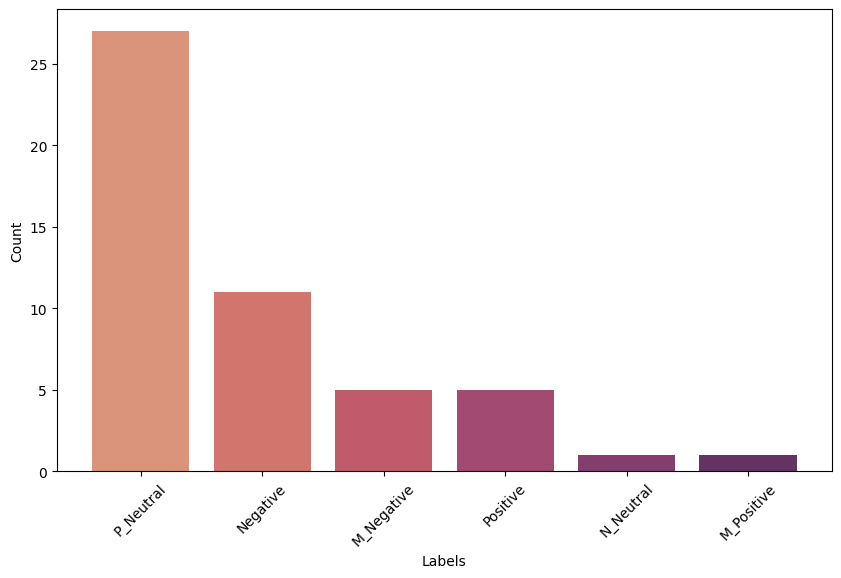

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.barplot(x=df1_labels.index, y=df1_labels.values, hue=df1_labels.index, palette='flare', legend=False)
plt.xlabel('Labels')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.plot()

## Label distribution, non-procedural speeches only

In [26]:
df2 = df1[df1['chair'] != True]
df2_labels = df2['final_tag'].value_counts()
df2_labels

final_tag
Negative      11
Positive       5
P_Neutral      4
M_Negative     4
M_Positive     1
Name: count, dtype: int64

[]

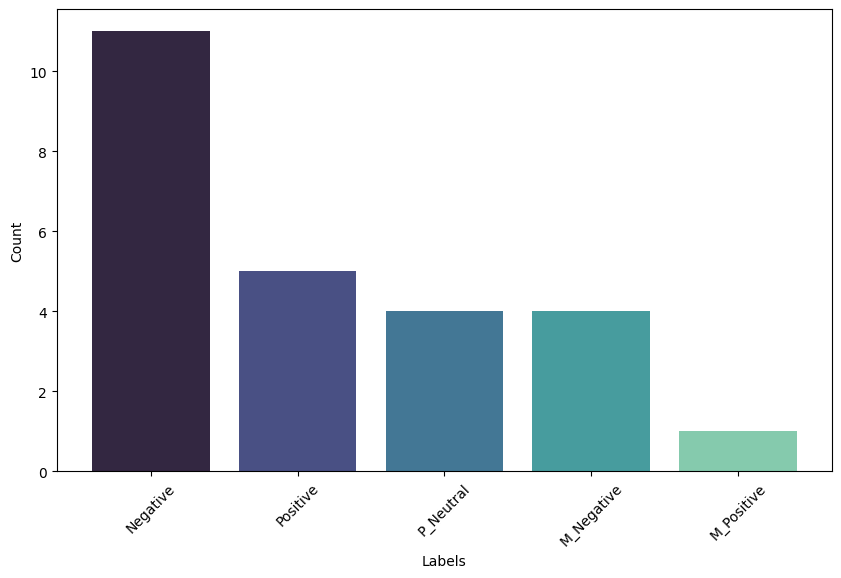

In [65]:
plt.figure(figsize=(10,6))
sns.barplot(x=df2_labels.index, y=df2_labels.values, hue=df2_labels.index, palette='mako', legend=False)
plt.xlabel('Labels')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.plot()

# Label distribution per annotators

In [56]:
annotator1_labels = df1['tag_tamara'].value_counts()
annotator2_labels = df1['tag_katja'].value_counts()
annotators = pd.DataFrame({
    'annotator1': annotator1_labels,
    'annotator2': annotator2_labels
})
#annotators.head()

In [57]:
annotators = annotators.reset_index().rename(columns={'index':'label'})

In [58]:
annotators = annotators.melt(id_vars='label', var_name='annotator', value_name='count')
annotators

,label,annotator,count
0,M_Negative,annotator1,3
1,M_Positive,annotator1,2
2,N_Neutral,annotator1,1
3,Negative,annotator1,12
4,P_Neutral,annotator1,24
5,Positive,annotator1,8
6,M_Negative,annotator2,4
7,M_Positive,annotator2,1
8,N_Neutral,annotator2,1
9,Negative,annotator2,13


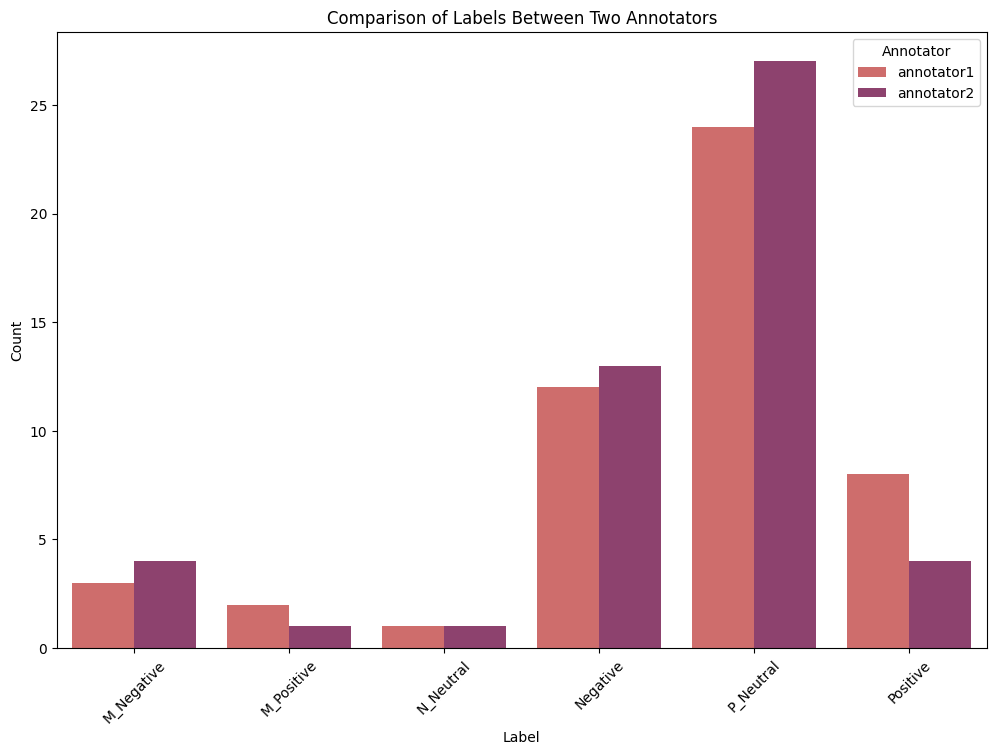

In [66]:
plt.figure(figsize=(12, 8))
sns.barplot(x='label', y='count', hue='annotator', data=annotators, palette='flare')
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Comparison of Labels Between Two Annotators')
plt.xticks(rotation=45)  
plt.legend(title='Annotator')
plt.show()

## Label distribution per annotator - non-procedural only

In [60]:
annotator1_labels = df2['tag_tamara'].value_counts()
annotator2_labels = df2['tag_katja'].value_counts()
annotators_non = pd.DataFrame({
    'annotator1': annotator1_labels,
    'annotator2': annotator2_labels
})
#annotators.head()

In [61]:
annotators_non = annotators_non.reset_index().rename(columns={'index':'label'})
annotators_non = annotators_non.melt(id_vars='label', var_name='annotator', value_name='count')
annotators_non

,label,annotator,count
0,M_Negative,annotator1,2
1,M_Positive,annotator1,2
2,Negative,annotator1,12
3,P_Neutral,annotator1,1
4,Positive,annotator1,8
5,M_Negative,annotator2,4
6,M_Positive,annotator2,1
7,Negative,annotator2,12
8,P_Neutral,annotator2,4
9,Positive,annotator2,4


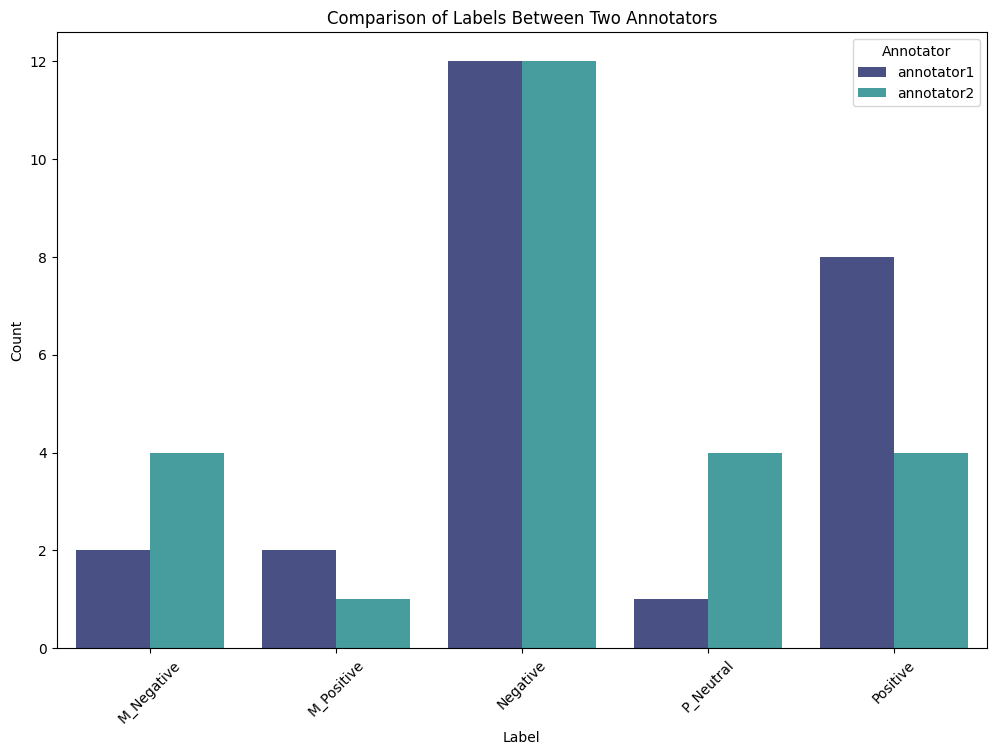

In [67]:
plt.figure(figsize=(12, 8))
sns.barplot(x='label', y='count', hue='annotator', data=annotators_non, palette='mako')
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Comparison of Labels Between Two Annotators')
plt.xticks(rotation=45)  
plt.legend(title='Annotator')
plt.show()